In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

df = pd.read_csv('../data/crime_clustered.csv')
print(df.shape)

# Select features for dimensionality reduction
features = ['Latitude', 'Longitude', 'Hour', 'Month', 'Is_Weekend', 
            'Crime_Severity', 'District', 'Beat', 'Domestic', 'Arrest']

# Encode boolean columns
df['Is_Weekend'] = df['Is_Weekend'].astype(int)
df['Domestic'] = df['Domestic'].astype(int)
df['Arrest'] = df['Arrest'].astype(int)

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix: {X_scaled.shape}")

(500000, 30)
Feature matrix: (500000, 10)


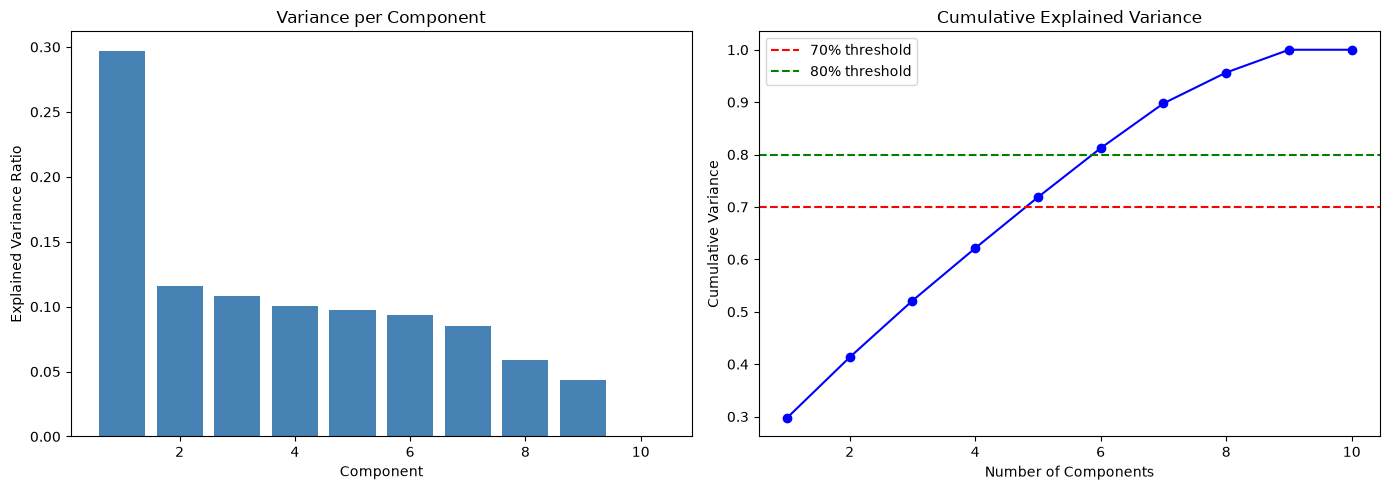

70% variance explained by 5 components
80% variance explained by 6 components
90% variance explained by 8 components


In [2]:
pca = PCA(n_components=len(features))
pca.fit(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained)+1), explained, color='steelblue')
ax1.set_title('Variance per Component')
ax1.set_xlabel('Component')
ax1.set_ylabel('Explained Variance Ratio')

ax2.plot(range(1, len(cumulative)+1), cumulative, 'bo-')
ax2.axhline(y=0.70, color='r', linestyle='--', label='70% threshold')
ax2.axhline(y=0.80, color='g', linestyle='--', label='80% threshold')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

# Print how many components needed
for threshold in [0.70, 0.80, 0.90]:
    n = np.argmax(cumulative >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n} components")

Top features by importance:
Crime_Severity    0.709590
Domestic          0.672095
District          0.586210
Beat              0.585861
Longitude         0.528543
Latitude          0.508555
Arrest            0.295129
Is_Weekend        0.267325
Hour              0.166537
Month             0.010861
dtype: float64


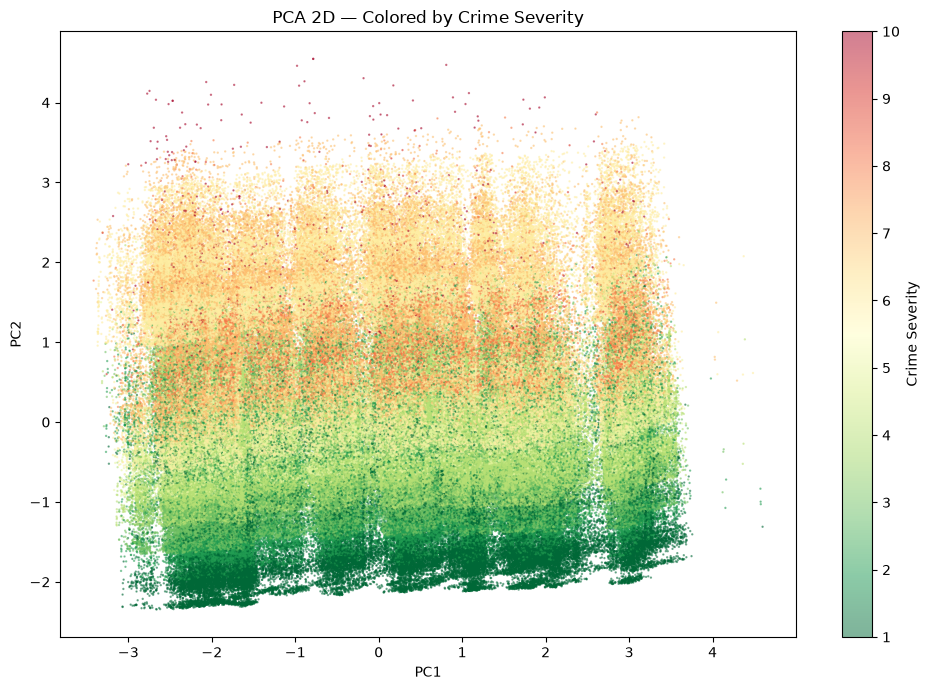

In [3]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Feature importance
print("Top features by importance:")
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)
print(loadings.abs().sum(axis=1).sort_values(ascending=False))

# Plot colored by crime severity
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Crime_Severity'], cmap='RdYlGn_r',
                      s=0.5, alpha=0.5)
plt.colorbar(scatter, label='Crime Severity')
plt.title('PCA 2D — Colored by Crime Severity')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

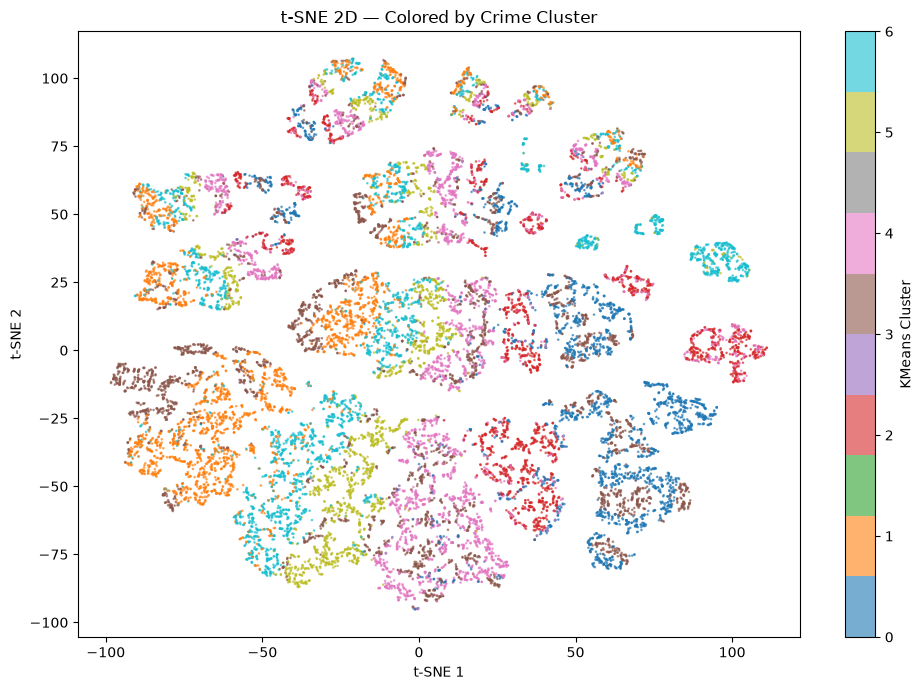

In [5]:
# Sample for t-SNE
sample_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_sample = X_scaled[sample_idx]
labels_sample = df['KMeans_Cluster'].iloc[sample_idx].values

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=labels_sample, cmap='tab10',
                      s=0.8, alpha=0.6)
plt.colorbar(scatter, label='KMeans Cluster')
plt.title('t-SNE 2D — Colored by Crime Cluster')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [6]:
# Save PCA components back to main df
pca_full = PCA(n_components=3)
X_pca3 = pca_full.fit_transform(X_scaled)

df['PC1'] = X_pca3[:, 0]
df['PC2'] = X_pca3[:, 1]
df['PC3'] = X_pca3[:, 2]

df.to_csv('../data/crime_final.csv', index=False)
print("Saved → data/crime_final.csv")

Saved → data/crime_final.csv
